<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timeseries_analysis_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_866/1598562047.py:8: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv("/content/AirQualityUCI.csv", sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)
/tmp/ipykernel_866/1598562047.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("/content/AirQualityUCI.csv", sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)
/tmp/ipykernel_866/1598562047.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ts_data = df['CO(GT)'].ffill().astype(floa

MAE               : 0.1900
RMSE              : 0.0652
R² Score          : 0.9243
Adjusted R² Score : 0.9229


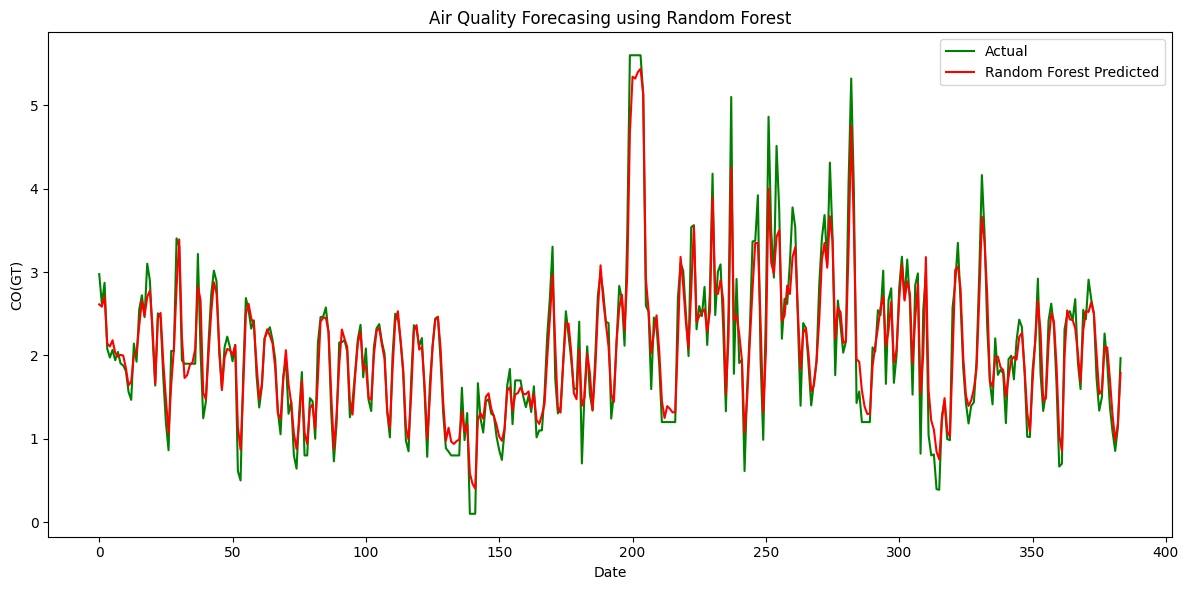

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# 1. Load and Preprocess the UCI Air Quality Dataset
df = pd.read_csv("/content/AirQualityUCI.csv", sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)
#data preprocessing
df.dropna(how='all', inplace=True)
df = df.iloc[:, :15]
df['Date_Time'] = pd.to_datetime(df['Date_Time'], format='%d/%m/%Y %H.%M.%S', errors='coerce')
df.dropna(subset=['Date_Time'], inplace=True)
df.set_index('Date_Time', inplace=True)
# Replace missing values (-200) and forward fill
df.replace(-200, pd.NA, inplace=True)
ts_data = df['CO(GT)'].ffill().astype(float)
# Resample to daily frequency to match the target data density
ts_data = ts_data.resample('D').mean().ffill()

# 2. Convert Time Series to Supervised Learning (Lag Features)
# We will use the past 7 days of CO levels to predict today's level
look_back = 7
data_dict = {'Target': ts_data}

for i in range(1, look_back + 1):
    data_dict[f'Lag_{i}'] = ts_data.shift(i)

features_df = pd.DataFrame(data_dict).dropna()

# Split into inputs (X) and target outputs (y)
X = features_df.drop(columns=['Target'])
y = features_df['Target']

# Fit the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)
#Forecasting of model
predictions = rf_model.predict(X)
actual_values = y.reset_index(drop=True)
#Accuracy metrics
y_true = actual_values
y_pred = predictions

# MAE, RMSE, and R2
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# Adjusted R2
n = len(y_true)  # Number of data points in test set
p = X.shape[1]  # Number of features/predictors used (3 lags)
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print(f"MAE               : {mae:.4f}")
print(f"RMSE              : {rmse:.4f}")
print(f"R² Score          : {r2:.4f}")
print(f"Adjusted R² Score : {adjusted_r2:.4f}")
#Displaying result
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(actual_values, label='Actual', color='green', linewidth=1.5)
plt.plot(predictions, label='Random Forest Predicted', color='red', linewidth=1.5)
plt.title('Air Quality Forecasing using Random Forest', fontsize=12)
plt.xlabel('Date', fontsize=10)
plt.ylabel('CO(GT)', fontsize=10)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()